In [1]:
#import relevant libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns
sns.set()

In [3]:
#load the data-set
raw_data=pd.read_csv('Bank_data.csv')
raw_data.head()

,Unnamed: 0,interest_rate,credit,march,may,previous,duration,y
0,0,1.334,0.0,1.0,0.0,0.0,117.0,no
1,1,0.767,0.0,0.0,2.0,1.0,274.0,yes
2,2,4.858,0.0,1.0,0.0,0.0,167.0,no
3,3,4.120,0.0,0.0,0.0,0.0,686.0,yes
4,4,4.856,0.0,1.0,0.0,0.0,157.0,no


In [9]:

data=raw_data.copy()
data=data.drop(['Unnamed: 0'], axis=1)
data['y']=data['y'].map({'yes':1,'no':0})
data

,interest_rate,credit,march,may,previous,duration,y
0,1.334,0.0,1.0,0.0,0.0,117.0,0
1,0.767,0.0,0.0,2.0,1.0,274.0,1
2,4.858,0.0,1.0,0.0,0.0,167.0,0
3,4.120,0.0,0.0,0.0,0.0,686.0,1
4,4.856,0.0,1.0,0.0,0.0,157.0,0
...,...,...,...,...,...,...,...
513,1.334,0.0,1.0,0.0,0.0,204.0,0
514,0.861,0.0,0.0,2.0,1.0,806.0,1
515,0.879,0.0,0.0,0.0,0.0,290.0,0
516,0.877,0.0,0.0,5.0,1.0,473.0,1


In [10]:
data.describe()

,interest_rate,credit,march,may,previous,duration,y
count,518.000000,518.000000,518.000000,518.000000,518.000000,518.000000,518.000000
mean,2.835776,0.034749,0.266409,0.388031,0.127413,382.177606,0.500000
std,1.876903,0.183321,0.442508,0.814527,0.333758,344.295990,0.500483
min,0.635000,0.000000,0.000000,0.000000,0.000000,9.000000,0.000000
25%,1.042750,0.000000,0.000000,0.000000,0.000000,155.000000,0.000000
50%,1.466000,0.000000,0.000000,0.000000,0.000000,266.500000,0.500000
75%,4.956500,0.000000,1.000000,0.000000,0.000000,482.750000,1.000000
max,4.970000,1.000000,1.000000,5.000000,1.000000,2653.000000,1.000000


In [5]:
#Declare the dependent and independent variables
y=data['y']
x1=data['duration']

In [7]:
#simple logistic Regression
x=sm.add_constant(x1)
regs_log=sm.Logit(y,x)
results_log=reg_logs.fit()

Optimization terminated successfully.
         Current function value: 0.546118
         Iterations 7


In [8]:
results_log.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                      y   No. Observations:                  518
Model:                          Logit   Df Residuals:                      516
Method:                           MLE   Df Model:                            1
Date:                Tue, 05 May 2026   Pseudo R-squ.:                  0.2121
Time:                        02:56:20   Log-Likelihood:                -282.89
converged:                       True   LL-Null:                       -359.05
Covariance Type:            nonrobust   LLR p-value:                 5.387e-35
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.7001      0.192     -8.863      0.000      -2.076      -1.324
duration       0.0051      0.001      9.159      0.000       0.004       0.006
==============================================================================
"""

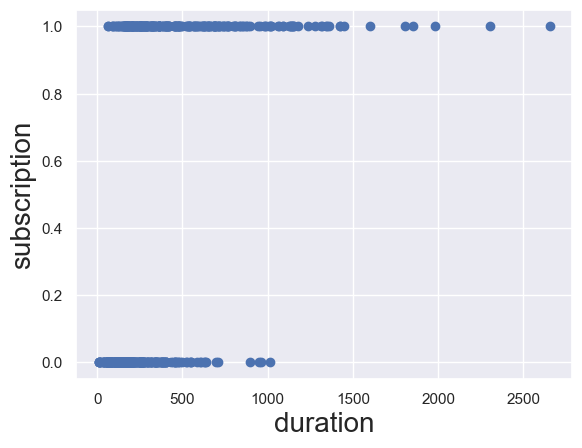

In [13]:
plt.scatter(x1,y, color='C0')
plt.xlabel('duration', fontsize=20)
plt.ylabel('subscription', fontsize=20)
plt.show()

In [14]:
np.exp(0.0051)

np.float64(1.005113027136717)

In [16]:
data.head()

,interest_rate,credit,march,may,previous,duration,y
0,1.334,0.0,1.0,0.0,0.0,117.0,0
1,0.767,0.0,0.0,2.0,1.0,274.0,1
2,4.858,0.0,1.0,0.0,0.0,167.0,0
3,4.120,0.0,0.0,0.0,0.0,686.0,1
4,4.856,0.0,1.0,0.0,0.0,157.0,0


In [27]:
#let expand the model by adding the remaining features
estimators=['duration','previous','may','march','credit','interest_rate']

y=data['y']
X1=data[estimators]

In [32]:
X=sm.add_constant(X1)
reg_logit=sm.Logit(y,X)
results_logit=reg_logit.fit()
results_logit.summary2()

Optimization terminated successfully.
         Current function value: 0.335942
         Iterations 7


<class 'statsmodels.iolib.summary2.Summary'>
"""
                         Results: Logit
=================================================================
Model:              Logit            Method:           MLE       
Dependent Variable: y                Pseudo R-squared: 0.515     
Date:               2026-05-05 08:54 AIC:              362.0356  
No. Observations:   518              BIC:              391.7855  
Df Model:           6                Log-Likelihood:   -174.02   
Df Residuals:       511              LL-Null:          -359.05   
Converged:          1.0000           LLR p-value:      7.5788e-77
No. Iterations:     7.0000           Scale:            1.0000    
-----------------------------------------------------------------
                   Coef.  Std.Err.    z    P>|z|   [0.025  0.975]
-----------------------------------------------------------------
const             -0.1385   0.3395 -0.4080 0.6833 -0.8039  0.5269
duration           0.0070   0.0007  9.3864 0.0000  0.0055  0.0084
previous           1.2746   0.5831  2.1861 0.0288  0.1319  2.4174
may                0.1946   0.2293  0.8488 0.3960 -0.2548  0.6440
march             -1.8097   0.3315 -5.4585 0.0000 -2.4594 -1.1599
credit             2.4028   1.0895  2.2053 0.0274  0.2673  4.5382
interest_rate     -0.7802   0.0921 -8.4712 0.0000 -0.9607 -0.5997
=================================================================

"""

In [74]:
###confusion matrix
#Find the confusion matrix of the model and estimate its accuracy. 
from sklearn.metrics import confusion_matrix, accuracy_score

def eval_classifier(model, X, y, threshold=0.5):
    """
    Evaluate a binary classifier.
    
    Parameters:
    model : fitted classifier
    X : features
    y : actual values (0/1)
    threshold : cutoff for predicting class 1 (default 0.5)
    """
    pred_probs = model.predict(X)
    pred_class = [1 if p >= threshold else 0 for p in pred_probs]
    
    cm = confusion_matrix(y, pred_class)
    acc = accuracy_score(y, pred_class)
    
    print(f"Threshold: {threshold}")
    print("Confusion Matrix:")
    print(cm)
    print(f"Accuracy: {acc:.4f}")
    

In [75]:
eval_classifier(results_logit,X,y, threshold=0.5)

Threshold: 0.5
Confusion Matrix:
[[220  39]
 [ 31 228]]
Accuracy: 0.8649


###testing our model on a new data-set

In [68]:
#load the new data-set
raw_data2=pd.read_csv("Bank_data_testing.csv")
raw_data2.head()

,Unnamed: 0,interest_rate,credit,march,may,previous,duration,y
0,0,1.313,0.0,1.0,0.0,0.0,487.0,no
1,1,4.961,0.0,0.0,0.0,0.0,132.0,no
2,2,4.856,0.0,1.0,0.0,0.0,92.0,no
3,3,4.120,0.0,0.0,0.0,0.0,1468.0,yes
4,4,4.963,0.0,0.0,0.0,0.0,36.0,no


In [69]:
data_test=raw_data2.copy()
data_test=data_test.drop(['Unnamed: 0'], axis=1)
data_test['y']=data_test['y'].map({'yes':1,'no':0})
data_test

,interest_rate,credit,march,may,previous,duration,y
0,1.313,0.0,1.0,0.0,0.0,487.0,0
1,4.961,0.0,0.0,0.0,0.0,132.0,0
2,4.856,0.0,1.0,0.0,0.0,92.0,0
3,4.120,0.0,0.0,0.0,0.0,1468.0,1
4,4.963,0.0,0.0,0.0,0.0,36.0,0
...,...,...,...,...,...,...,...
217,4.963,0.0,0.0,0.0,0.0,458.0,1
218,1.264,0.0,1.0,1.0,0.0,397.0,1
219,1.281,0.0,1.0,0.0,0.0,34.0,0
220,0.739,0.0,0.0,2.0,0.0,233.0,0


In [70]:
#declear the dependent and independent variable
y_test=data_test['y']
X1_test=data_test[estimators]
X_test=sm.add_constant(X1_test)

In [ ]:
###Determine the test confusion matrix and the test accuracy 
##and compare them with the train confusion matrix and the train accuracy.

In [76]:
#Testing
eval_classifier(results_logit, X_test, y_test, threshold=0.5)

Threshold: 0.5
Confusion Matrix:
[[94 17]
 [12 99]]
Accuracy: 0.8694


In [82]:
#Training
eval_classifier(results_logit, X,y, threshold=0.5)

Threshold: 0.5
Confusion Matrix:
[[220  39]
 [ 31 228]]
Accuracy: 0.8649
